In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/user_behavior_dataset.csv")

data

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3
...,...,...,...,...,...,...,...,...,...,...,...
695,696,iPhone 12,iOS,92,3.9,1082,26,381,22,Male,2
696,697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4
697,698,Google Pixel 5,Android,99,3.1,942,22,457,50,Female,2
698,699,Samsung Galaxy S21,Android,62,1.7,431,13,224,44,Male,1


In [ ]:
print(data.columns)

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')


In [ ]:
grup = data.groupby('User Behavior Class').agg({"User Behavior Class": "count"})
grup_prop = grup / len(data)

print(grup)
print(grup_prop)

                     User Behavior Class
User Behavior Class                     
1                                    136
2                                    146
3                                    143
4                                    139
5                                    136
                     User Behavior Class
User Behavior Class                     
1                               0.194286
2                               0.208571
3                               0.204286
4                               0.198571
5                               0.194286


In [ ]:
summary = data.groupby('User Behavior Class').agg({
    # Select only numeric columns for the mean calculation
    col: 'mean' for col in data.select_dtypes(include=np.number).columns
}).transpose()

print(summary)

User Behavior Class                  1           2            3            4  \
User ID                     347.772059  355.363014   362.062937   345.208633   
App Usage Time (min/day)     60.426471  131.972603   235.398601   395.748201   
Screen On Time (hours/day)    1.490441    3.037671     4.955944     6.909353   
Battery Drain (mAh/day)     454.977941  883.808219  1515.055944  2105.805755   
Number of Apps Installed     14.558824   30.753425    50.000000    69.920863   
Data Usage (MB/day)         202.323529  451.417808   822.013986  1232.230216   
Age                          38.213235   38.643836    38.678322    38.676259   
User Behavior Class           1.000000    2.000000     3.000000     4.000000   

User Behavior Class                   5  
User ID                      341.257353  
App Usage Time (min/day)     541.419118  
Screen On Time (hours/day)    10.114706  
Battery Drain (mAh/day)     2701.014706  
Number of Apps Installed      89.250000  
Data Usage (MB/day)        

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


# Membagi dataset
X = data.drop(['User Behavior Class', 'User ID'], axis=1)
y = data['User Behavior Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pastikan semua kolom kategoris
categorical_features = ['Device Model', 'Operating System', 'Gender']

# Buat preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Sisakan kolom numerik
)

# Terapkan preprocessor hanya di data pelatihan
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Standarisasi setelah encoding
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train_encoded)
scaled_X_test = scaler.transform(X_test_encoded)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# help(KNeighborsClassifier)

knn_model = KNeighborsClassifier(n_neighbors=5)

# Membuat model berdasarkan data training
knn_model.fit(scaled_X_train, y_train)

# Memprediksi output dari data testing
y_pred = knn_model.predict(scaled_X_test)

# menampilkan confusion matriks
print(confusion_matrix(y_test, y_pred))

# menampilkan nilai akurasi dan metrik lainnya
print(classification_report(y_test, y_pred))

[[41  5  0  0  0]
 [ 0 34  0  0  0]
 [ 0  8 42  0  0]
 [ 0  0  1 46  0]
 [ 0  0  0  0 33]]
              precision    recall  f1-score   support

           1       1.00      0.89      0.94        46
           2       0.72      1.00      0.84        34
           3       0.98      0.84      0.90        50
           4       1.00      0.98      0.99        47
           5       1.00      1.00      1.00        33

    accuracy                           0.93       210
   macro avg       0.94      0.94      0.93       210
weighted avg       0.95      0.93      0.94       210



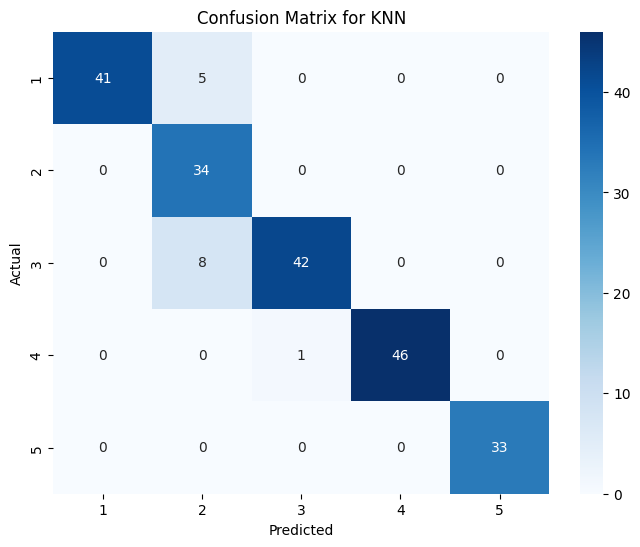

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix for KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

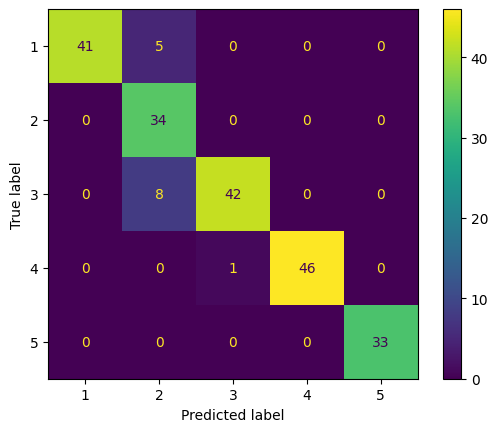

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Import ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).from_predictions(y_true=y_test, y_pred=y_pred);

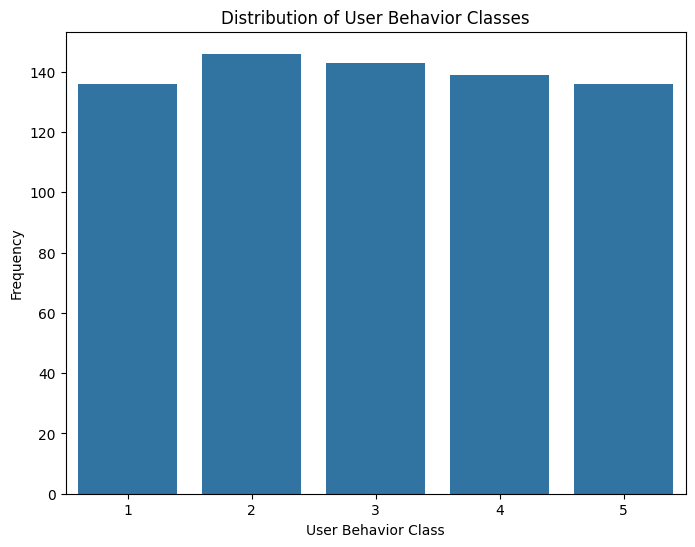

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribution of User Behavior Classes')
plt.xlabel('User Behavior Class')
plt.ylabel('Frequency')
plt.show()